# Visualizações da seleção de instâncias no CIFAR-10

Este notebook gera visualizações a partir dos arquivos:

- `/scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_all_predictions.csv`
- `/scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_correct_grouped_by_confidence.csv`
- `/scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_correct_predictions.csv`
- `/scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_selected_instances.csv`
- `/scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_selected_instances_representative_1.csv`

## O que o notebook faz

1. Carrega e valida os CSVs
2. Mostra visão geral dos dados
3. Gera:
   - distribuição de confiança por classe
   - quartis por classe
   - histogramas de confiança por classe
   - heatmap classe × faixa de confiança
   - distribuição da margem por classe
   - comparação entre todos os corretos, o subconjunto de 5 por estrato e o subconjunto representativo de 1 por estrato
   - visualização dos exemplos selecionados sobre a distribuição
   - comparação direta entre seleção aleatória estratificada e seleção representativa
4. Salva as figuras em uma pasta `figures_instance_selection/`

> Observação: o notebook foi feito para ser robusto a pequenas diferenças de colunas.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Configuração de caminhos
BASE_DIR = Path("/scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs")
ALL_PRED_PATH = BASE_DIR / "cifar10_all_predictions.csv"
CORRECT_GROUPED_PATH = BASE_DIR / "cifar10_correct_grouped_by_confidence.csv"
CORRECT_PATH = BASE_DIR / "cifar10_correct_predictions.csv"
SELECTED_PATH = BASE_DIR / "cifar10_selected_instances.csv"
SELECTED_REP1_PATH = BASE_DIR / "cifar10_selected_instances_representative_1.csv"

OUTPUT_DIR = BASE_DIR.parent / "figures_instance_selection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATHS = {
    "all_predictions": ALL_PRED_PATH,
    "correct_grouped": CORRECT_GROUPED_PATH,
    "correct_predictions": CORRECT_PATH,
    "selected_instances": SELECTED_PATH,
    "selected_representative_1": SELECTED_REP1_PATH,
}

for name, path in CSV_PATHS.items():
    print(f"{name}: {path} | exists={path.exists()}")

all_predictions: /scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_all_predictions.csv | exists=True
correct_grouped: /scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_correct_grouped_by_confidence.csv | exists=True
correct_predictions: /scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_correct_predictions.csv | exists=True
selected_instances: /scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_selected_instances.csv | exists=True
selected_representative_1: /scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/outputs/cifar10_selected_instances_representative_1.csv | exists=True


In [2]:
def load_csv_checked(path: Path, name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {path}\n"
            f"Verifique se o caminho está correto para {name}."
        )
    df = pd.read_csv(path)
    print(f"\n{name}")
    print(f"shape={df.shape}")
    print(f"columns={list(df.columns)}")
    return df

all_df = load_csv_checked(ALL_PRED_PATH, "all_predictions")
grouped_df = load_csv_checked(CORRECT_GROUPED_PATH, "correct_grouped")
correct_df = load_csv_checked(CORRECT_PATH, "correct_predictions")
selected_df = load_csv_checked(SELECTED_PATH, "selected_instances")
selected_rep1_df = load_csv_checked(SELECTED_REP1_PATH, "selected_representative_1")


all_predictions
shape=(10000, 9)
columns=['dataset_index', 'true_label', 'true_label_name', 'pred_label', 'pred_label_name', 'confidence', 'margin', 'correct', 'confidence_group']

correct_grouped
shape=(9852, 11)
columns=['dataset_index', 'true_label', 'true_label_name', 'pred_label', 'pred_label_name', 'confidence', 'margin', 'correct', 'confidence_group', 'confidence_rank_within_class', 'confidence_percentile_within_class']

correct_predictions
shape=(9852, 9)
columns=['dataset_index', 'true_label', 'true_label_name', 'pred_label', 'pred_label_name', 'confidence', 'margin', 'correct', 'confidence_group']

selected_instances
shape=(150, 11)
columns=['dataset_index', 'true_label', 'true_label_name', 'pred_label', 'pred_label_name', 'confidence', 'margin', 'correct', 'confidence_group', 'confidence_rank_within_class', 'confidence_percentile_within_class']

selected_representative_1
shape=(30, 13)
columns=['dataset_index', 'true_label', 'true_label_name', 'pred_label', 'pred_label_name

In [3]:
def infer_column(df: pd.DataFrame, candidates, required=True):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f"Nenhuma das colunas candidatas encontrada: {candidates}")
    return None

def standardize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    label_col = infer_column(df, ["true_label_name", "label_name", "class_name", "true_label"])
    conf_col = infer_column(df, ["confidence", "pred_confidence", "prob", "score"])
    group_col = infer_column(df, ["confidence_group", "group"], required=False)
    margin_col = infer_column(df, ["margin", "margin_logit", "logit_margin"], required=False)
    correct_col = infer_column(df, ["correct", "is_correct"], required=False)
    index_col = infer_column(df, ["dataset_index", "index", "sample_index"], required=False)

    df["label_std"] = df[label_col].astype(str)
    df["confidence_std"] = pd.to_numeric(df[conf_col], errors="coerce")
    if group_col is not None:
        df["confidence_group_std"] = df[group_col].astype(str)
    if margin_col is not None:
        df["margin_std"] = pd.to_numeric(df[margin_col], errors="coerce")
    if correct_col is not None:
        df["correct_std"] = df[correct_col]
    if index_col is not None:
        df["index_std"] = df[index_col]

    return df

all_std = standardize_dataframe(all_df)
grouped_std = standardize_dataframe(grouped_df)
correct_std = standardize_dataframe(correct_df)
selected_std = standardize_dataframe(selected_df)
selected_rep1_std = standardize_dataframe(selected_rep1_df)

print("Padronização concluída.")

Padronização concluída.


## 1. Visão geral dos dados

In [4]:
summary_frames = {
    "all_predictions": all_std,
    "correct_grouped": grouped_std,
    "correct_predictions": correct_std,
    "selected_instances": selected_std,
    "selected_representative_1": selected_rep1_std,
}

for name, df in summary_frames.items():
    print(f"\n=== {name} ===")
    print(df.head(3))
    print(df[["label_std", "confidence_std"]].describe(include="all"))


=== all_predictions ===
   dataset_index  true_label true_label_name  pred_label pred_label_name  \
0              0           3         LABEL_3           3         LABEL_3   
1              1           8         LABEL_8           8         LABEL_8   
2              2           8         LABEL_8           8         LABEL_8   

   confidence    margin  correct  confidence_group label_std  confidence_std  \
0    0.992724  0.991428     True               NaN   LABEL_3        0.992724   
1    0.995523  0.994790     True               NaN   LABEL_8        0.995523   
2    0.993039  0.990617     True               NaN   LABEL_8        0.993039   

  confidence_group_std  margin_std  correct_std  index_std  
0                  NaN    0.991428         True          0  
1                  NaN    0.994790         True          1  
2                  NaN    0.990617         True          2  
       label_std  confidence_std
count      10000    10000.000000
unique        10             NaN
top   

In [5]:
# Conferência das seleções balanceadas
if "confidence_group_std" in selected_std.columns:
    selection_counts = (
        selected_std.groupby(["label_std", "confidence_group_std"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    print("Seleção de 5 por estrato:")
    display(selection_counts)

if "confidence_group_std" in selected_rep1_std.columns:
    selection_rep1_counts = (
        selected_rep1_std.groupby(["label_std", "confidence_group_std"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    print("Seleção representativa de 1 por estrato:")
    display(selection_rep1_counts)

Seleção de 5 por estrato:


confidence_group_std,high,low,medium
label_std,,,
LABEL_0,5,5,5
LABEL_1,5,5,5
LABEL_2,5,5,5
LABEL_3,5,5,5
LABEL_4,5,5,5
LABEL_5,5,5,5
LABEL_6,5,5,5
LABEL_7,5,5,5
LABEL_8,5,5,5


Seleção representativa de 1 por estrato:


confidence_group_std,high,low,medium
label_std,,,
LABEL_0,1,1,1
LABEL_1,1,1,1
LABEL_2,1,1,1
LABEL_3,1,1,1
LABEL_4,1,1,1
LABEL_5,1,1,1
LABEL_6,1,1,1
LABEL_7,1,1,1
LABEL_8,1,1,1


## 2. Distribuição de confiança por classe

Essas figuras ajudam a justificar a estratificação por confiança dentro de cada classe.

In [6]:
def sorted_labels(df: pd.DataFrame):
    labels = sorted(df["label_std"].unique())
    return labels

labels = sorted_labels(correct_std)

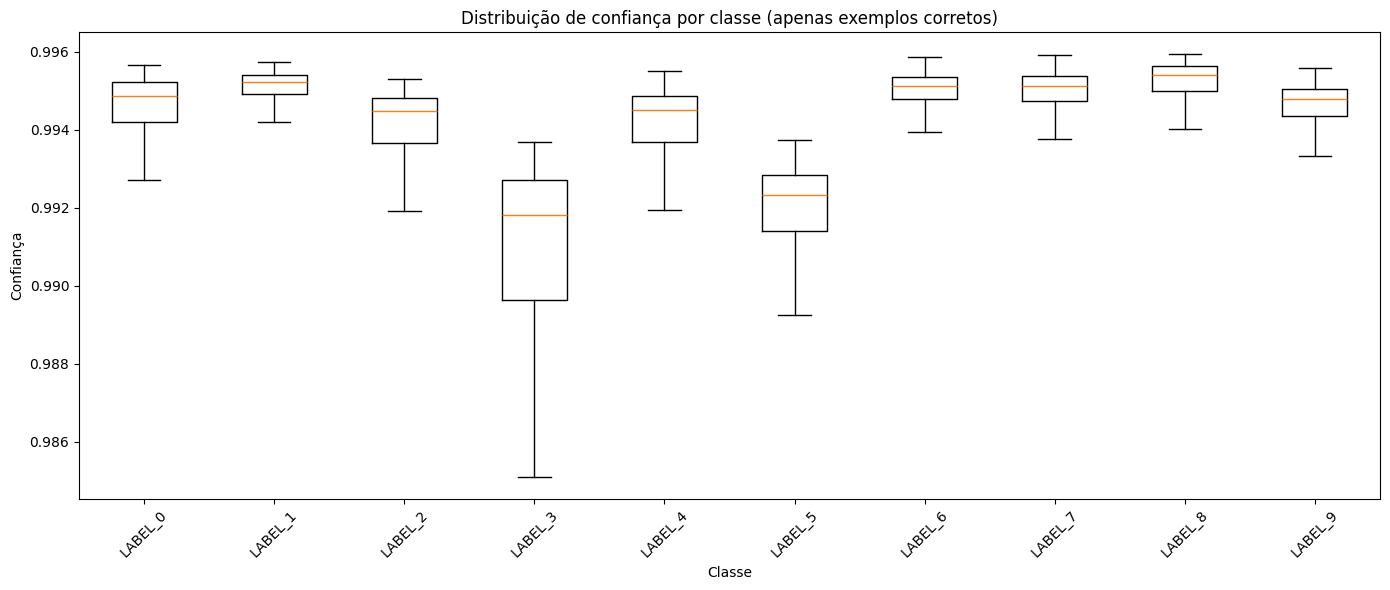

In [7]:
# Boxplot de confiança por classe
fig, ax = plt.subplots(figsize=(14, 6))

data = [correct_std.loc[correct_std["label_std"] == label, "confidence_std"].dropna().values for label in labels]
ax.boxplot(data, labels=labels, showfliers=False)

ax.set_title("Distribuição de confiança por classe (apenas exemplos corretos)")
ax.set_xlabel("Classe")
ax.set_ylabel("Confiança")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "boxplot_confidence_by_class.png", dpi=200)
plt.show()

In [8]:
# Quartis por classe
quartis = (
    correct_std.groupby("label_std")["confidence_std"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .rename(columns={0.25: "Q1", 0.5: "Median", 0.75: "Q3"})
    .sort_index()
)
quartis

,Q1,Median,Q3
label_std,,,
LABEL_0,0.994210,0.994873,0.995216
LABEL_1,0.994928,0.995226,0.995413
LABEL_2,0.993658,0.994478,0.994823
LABEL_3,0.989649,0.991810,0.992708
LABEL_4,0.993689,0.994507,0.994860
LABEL_5,0.991393,0.992330,0.992829
LABEL_6,0.994786,0.995121,0.995358
LABEL_7,0.994730,0.995125,0.995383
LABEL_8,0.994986,0.995416,0.995624


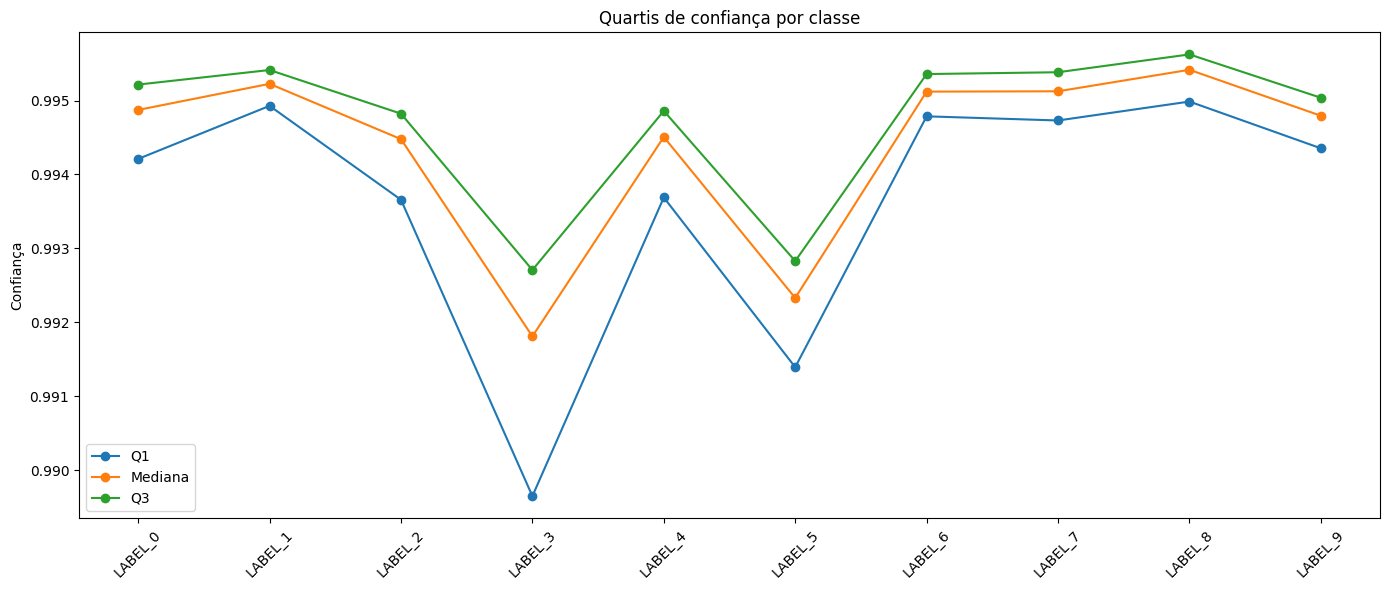

In [9]:
# Visualização dos quartis por classe
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(quartis))
ax.plot(x, quartis["Q1"].values, marker="o", label="Q1")
ax.plot(x, quartis["Median"].values, marker="o", label="Mediana")
ax.plot(x, quartis["Q3"].values, marker="o", label="Q3")

ax.set_xticks(x)
ax.set_xticklabels(quartis.index, rotation=45)
ax.set_ylabel("Confiança")
ax.set_title("Quartis de confiança por classe")
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "quartiles_confidence_by_class.png", dpi=200)
plt.show()

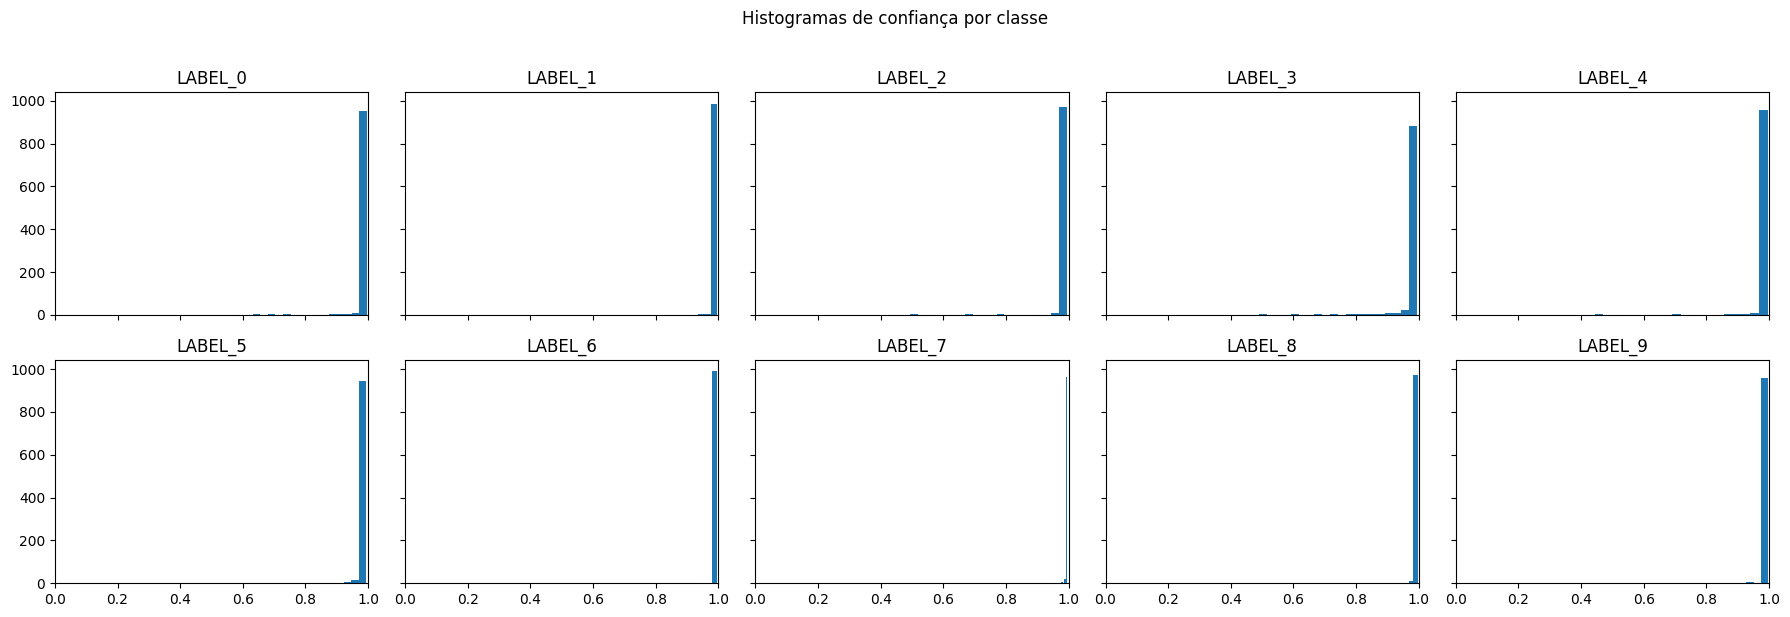

In [10]:
# Histogramas por classe
n_cols = 5
n_rows = int(np.ceil(len(labels) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6), sharex=True, sharey=True)
axes = np.array(axes).reshape(n_rows, n_cols)

for ax, label in zip(axes.flat, labels):
    vals = correct_std.loc[correct_std["label_std"] == label, "confidence_std"].dropna().values
    ax.hist(vals, bins=20)
    ax.set_title(label)
    ax.set_xlim(0, 1)

for ax in axes.flat[len(labels):]:
    ax.axis("off")

fig.suptitle("Histogramas de confiança por classe", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "hist_confidence_by_class.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Heatmaps classe × faixa de confiança

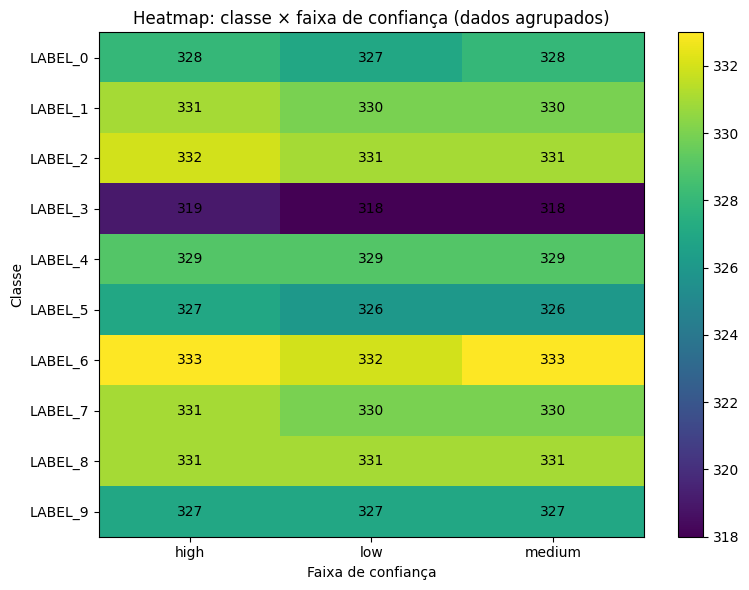

In [11]:
if "confidence_group_std" in grouped_std.columns:
    counts_grouped = (
        grouped_std.groupby(["label_std", "confidence_group_std"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(counts_grouped.values, aspect="auto")

    ax.set_xticks(np.arange(counts_grouped.shape[1]))
    ax.set_xticklabels(counts_grouped.columns)
    ax.set_yticks(np.arange(counts_grouped.shape[0]))
    ax.set_yticklabels(counts_grouped.index)
    ax.set_title("Heatmap: classe × faixa de confiança (dados agrupados)")
    ax.set_xlabel("Faixa de confiança")
    ax.set_ylabel("Classe")

    for i in range(counts_grouped.shape[0]):
        for j in range(counts_grouped.shape[1]):
            ax.text(j, i, counts_grouped.iloc[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "heatmap_class_confidence_group_grouped.png", dpi=200)
    plt.show()

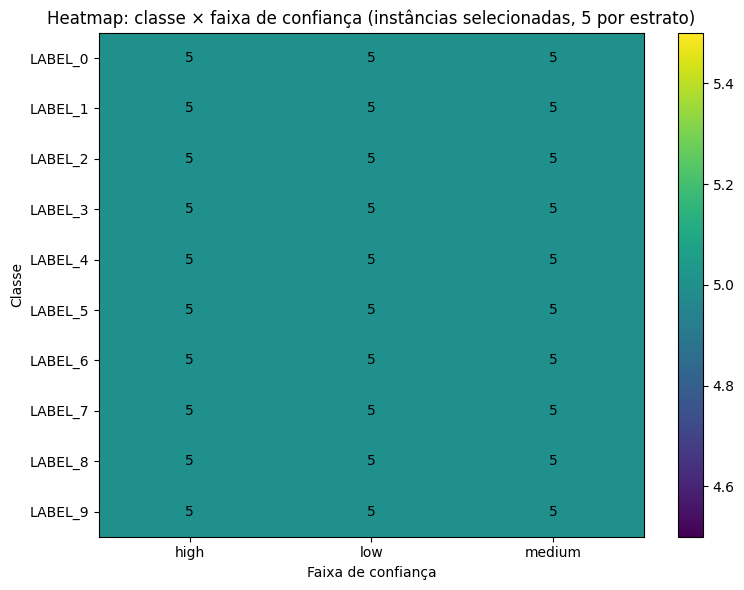

In [12]:
if "confidence_group_std" in selected_std.columns:
    counts_selected = (
        selected_std.groupby(["label_std", "confidence_group_std"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(counts_selected.values, aspect="auto")

    ax.set_xticks(np.arange(counts_selected.shape[1]))
    ax.set_xticklabels(counts_selected.columns)
    ax.set_yticks(np.arange(counts_selected.shape[0]))
    ax.set_yticklabels(counts_selected.index)
    ax.set_title("Heatmap: classe × faixa de confiança (instâncias selecionadas, 5 por estrato)")
    ax.set_xlabel("Faixa de confiança")
    ax.set_ylabel("Classe")

    for i in range(counts_selected.shape[0]):
        for j in range(counts_selected.shape[1]):
            ax.text(j, i, counts_selected.iloc[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "heatmap_class_confidence_group_selected.png", dpi=200)
    plt.show()

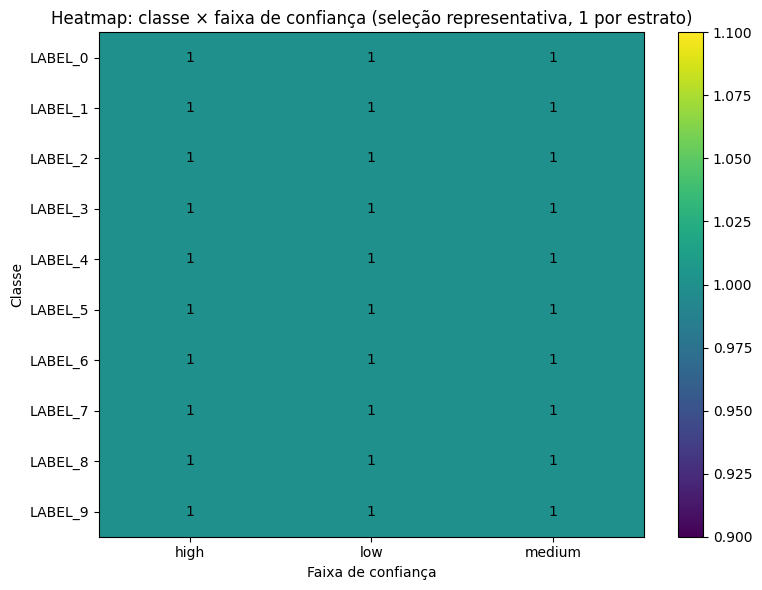

In [13]:
if "confidence_group_std" in selected_rep1_std.columns:
    counts_selected_rep1 = (
        selected_rep1_std.groupby(["label_std", "confidence_group_std"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(counts_selected_rep1.values, aspect="auto")

    ax.set_xticks(np.arange(counts_selected_rep1.shape[1]))
    ax.set_xticklabels(counts_selected_rep1.columns)
    ax.set_yticks(np.arange(counts_selected_rep1.shape[0]))
    ax.set_yticklabels(counts_selected_rep1.index)
    ax.set_title("Heatmap: classe × faixa de confiança (seleção representativa, 1 por estrato)")
    ax.set_xlabel("Faixa de confiança")
    ax.set_ylabel("Classe")

    for i in range(counts_selected_rep1.shape[0]):
        for j in range(counts_selected_rep1.shape[1]):
            ax.text(j, i, counts_selected_rep1.iloc[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "heatmap_class_confidence_group_selected_rep1.png", dpi=200)
    plt.show()

## 4. Distribuição da margem por classe

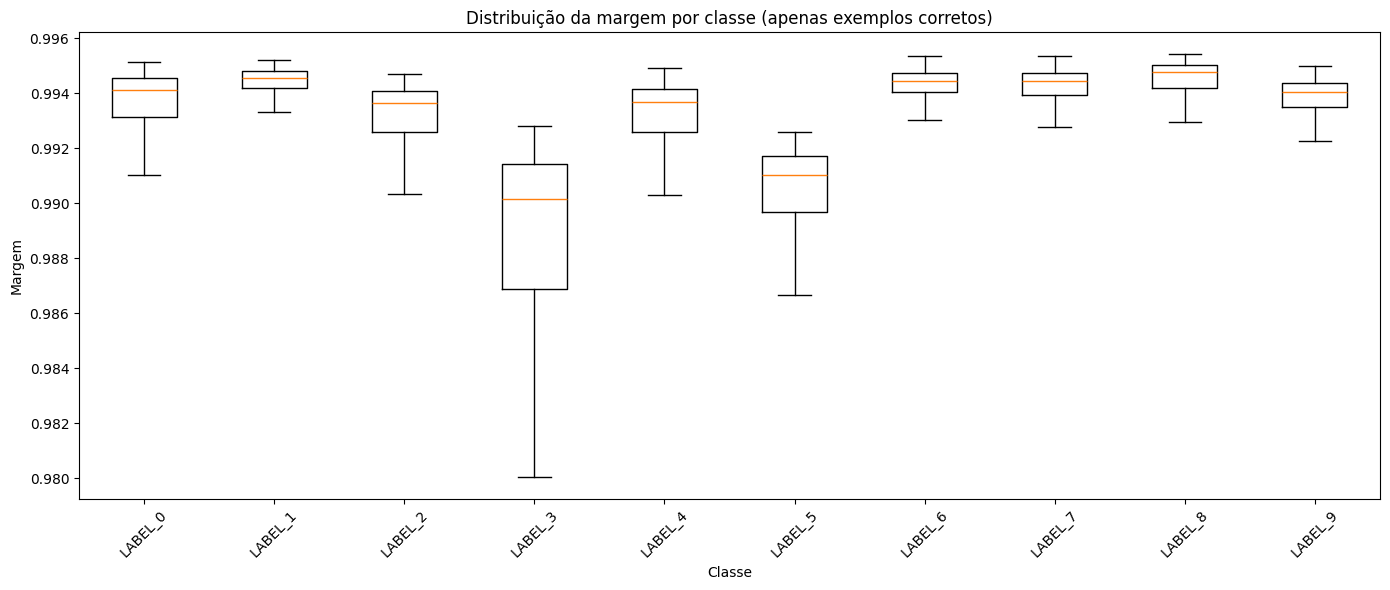

In [14]:
if "margin_std" in correct_std.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    data = [correct_std.loc[correct_std["label_std"] == label, "margin_std"].dropna().values for label in labels]
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title("Distribuição da margem por classe (apenas exemplos corretos)")
    ax.set_xlabel("Classe")
    ax.set_ylabel("Margem")
    ax.tick_params(axis="x", rotation=45)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "boxplot_margin_by_class.png", dpi=200)
    plt.show()
else:
    print("A coluna de margem não foi encontrada em correct_df.")

## 5. Comparação entre corretos, seleção de 5 e seleção representativa de 1

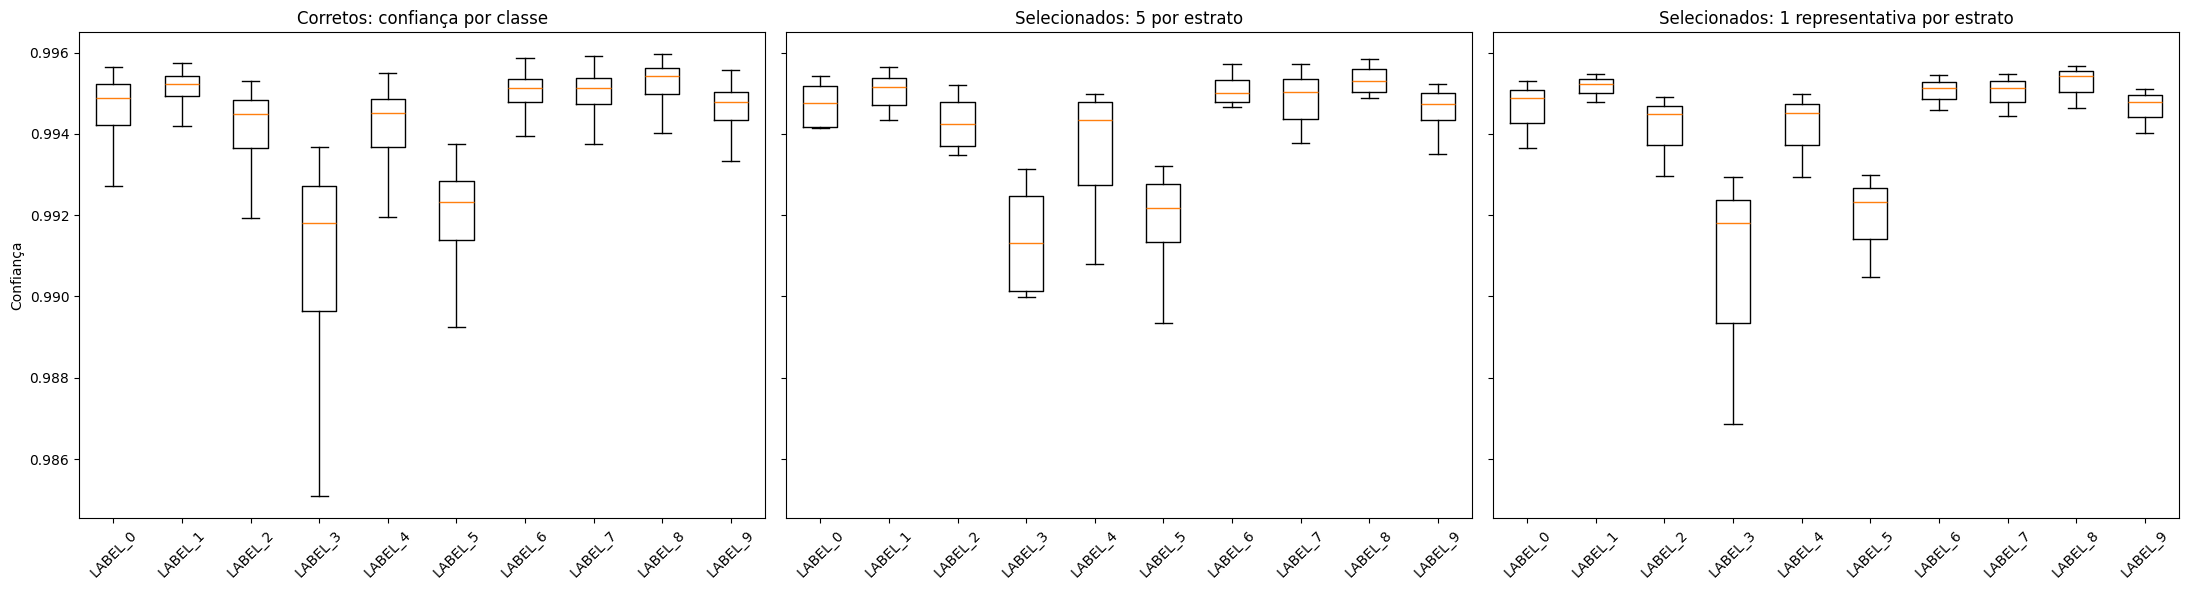

In [15]:
# Boxplot: corretos vs selecionados (5) vs representativos (1)
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

data_correct = [correct_std.loc[correct_std["label_std"] == label, "confidence_std"].dropna().values for label in labels]
data_selected = [selected_std.loc[selected_std["label_std"] == label, "confidence_std"].dropna().values for label in labels]
data_rep1 = [selected_rep1_std.loc[selected_rep1_std["label_std"] == label, "confidence_std"].dropna().values for label in labels]

axes[0].boxplot(data_correct, labels=labels, showfliers=False)
axes[0].set_title("Corretos: confiança por classe")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Confiança")

axes[1].boxplot(data_selected, labels=labels, showfliers=False)
axes[1].set_title("Selecionados: 5 por estrato")
axes[1].tick_params(axis="x", rotation=45)

axes[2].boxplot(data_rep1, labels=labels, showfliers=False)
axes[2].set_title("Selecionados: 1 representativa por estrato")
axes[2].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "compare_correct_vs_selected_vs_rep1_confidence_by_class.png", dpi=200)
plt.show()

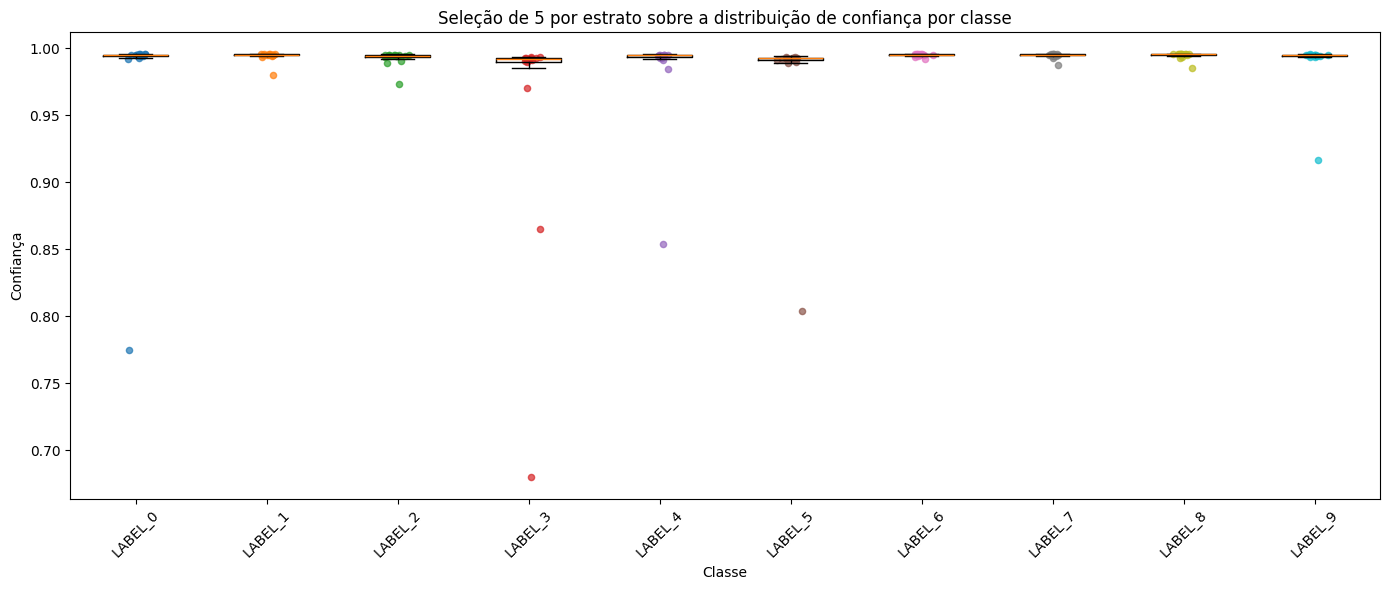

In [16]:
# Overlay dos pontos selecionados (5 por estrato) sobre os boxplots dos corretos
fig, ax = plt.subplots(figsize=(14, 6))

data = [correct_std.loc[correct_std["label_std"] == label, "confidence_std"].dropna().values for label in labels]
ax.boxplot(data, labels=labels, showfliers=False)

for i, label in enumerate(labels, start=1):
    sel_vals = selected_std.loc[selected_std["label_std"] == label, "confidence_std"].dropna().values
    if len(sel_vals) > 0:
        x_jitter = np.random.normal(loc=i, scale=0.04, size=len(sel_vals))
        ax.scatter(x_jitter, sel_vals, alpha=0.7, s=20, label=None)

ax.set_title("Seleção de 5 por estrato sobre a distribuição de confiança por classe")
ax.set_xlabel("Classe")
ax.set_ylabel("Confiança")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "selected5_points_over_confidence_boxplot.png", dpi=200)
plt.show()

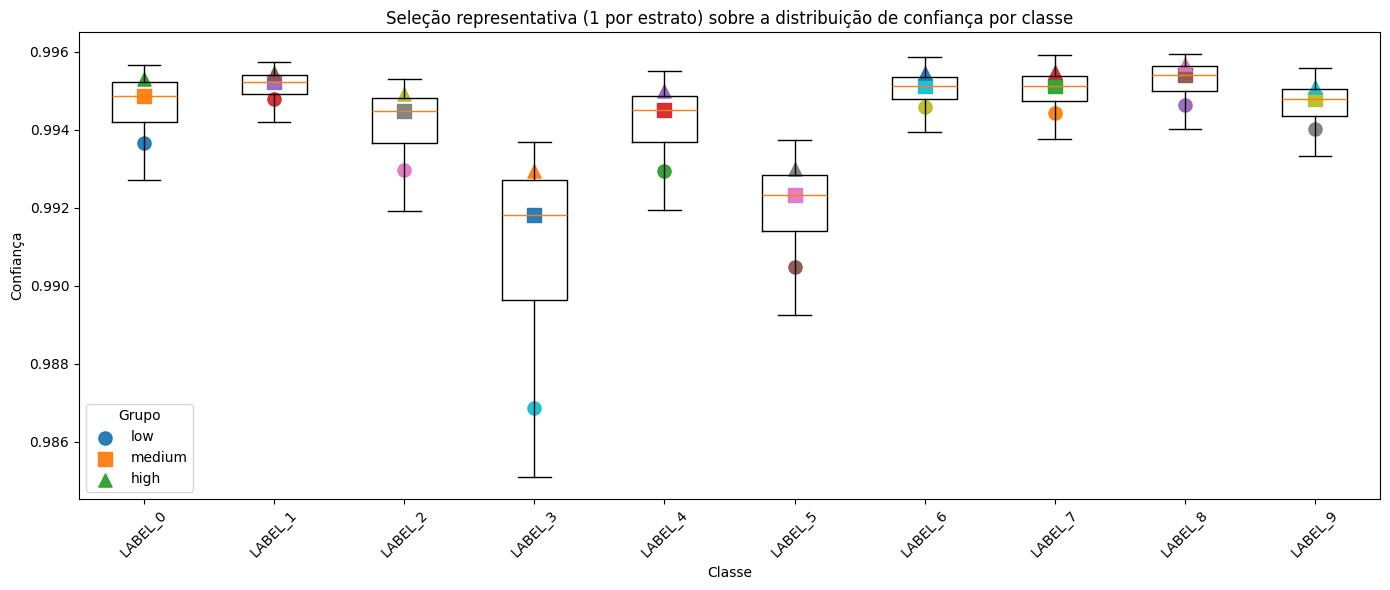

In [17]:
# Overlay dos pontos representativos (1 por estrato) sobre os boxplots dos corretos
fig, ax = plt.subplots(figsize=(14, 6))

data = [correct_std.loc[correct_std["label_std"] == label, "confidence_std"].dropna().values for label in labels]
ax.boxplot(data, labels=labels, showfliers=False)

group_order = ["low", "medium", "high"]
group_markers = {"low": "o", "medium": "s", "high": "^"}

for i, label in enumerate(labels, start=1):
    cls_df = selected_rep1_std.loc[selected_rep1_std["label_std"] == label].copy()
    for group in group_order:
        vals = cls_df.loc[cls_df["confidence_group_std"] == group, "confidence_std"].dropna().values             if "confidence_group_std" in cls_df.columns else np.array([])
        if len(vals) > 0:
            ax.scatter(
                [i],
                vals,
                s=90,
                marker=group_markers[group],
                alpha=0.95,
                label=group if i == 1 else None,
            )

ax.set_title("Seleção representativa (1 por estrato) sobre a distribuição de confiança por classe")
ax.set_xlabel("Classe")
ax.set_ylabel("Confiança")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Grupo", loc="best")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "selected_rep1_points_over_confidence_boxplot.png", dpi=200)
plt.show()

## 6. Comparação direta entre a seleção de 5 e a seleção representativa de 1

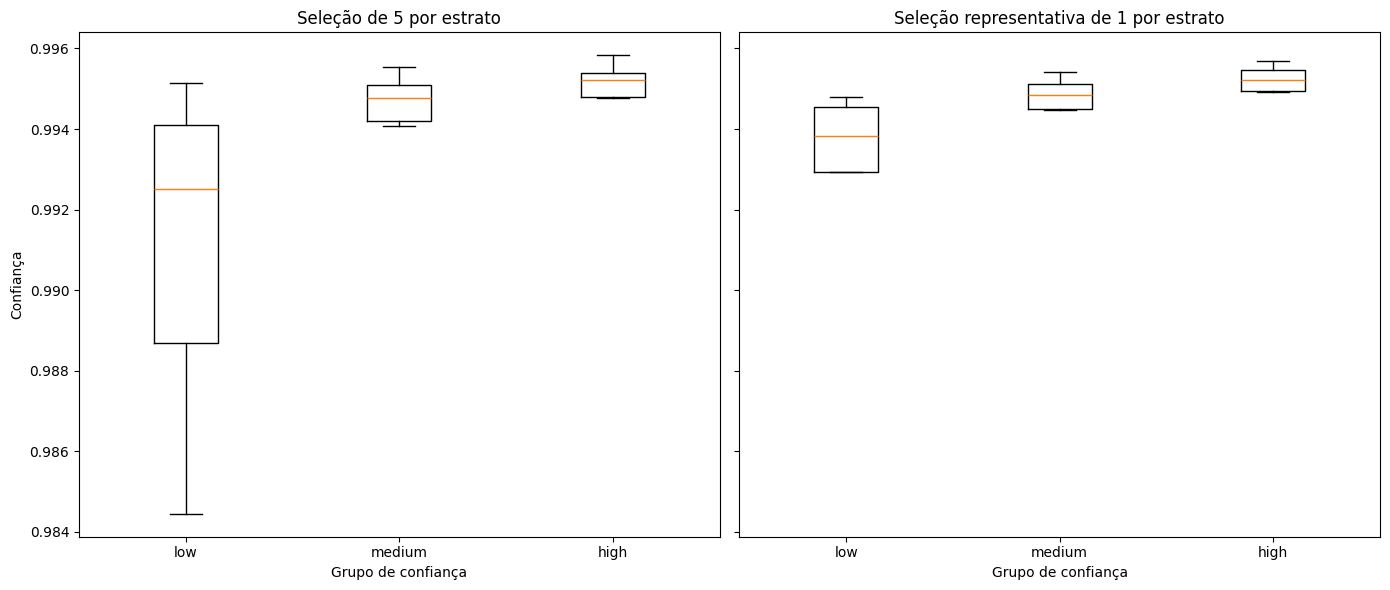

In [18]:
if "confidence_group_std" in selected_std.columns and "confidence_group_std" in selected_rep1_std.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    group_order = ["low", "medium", "high"]

    data_5 = [
        selected_std.loc[selected_std["confidence_group_std"] == g, "confidence_std"].dropna().values
        for g in group_order
    ]
    data_1 = [
        selected_rep1_std.loc[selected_rep1_std["confidence_group_std"] == g, "confidence_std"].dropna().values
        for g in group_order
    ]

    axes[0].boxplot(data_5, labels=group_order, showfliers=False)
    axes[0].set_title("Seleção de 5 por estrato")
    axes[0].set_xlabel("Grupo de confiança")
    axes[0].set_ylabel("Confiança")

    axes[1].boxplot(data_1, labels=group_order, showfliers=False)
    axes[1].set_title("Seleção representativa de 1 por estrato")
    axes[1].set_xlabel("Grupo de confiança")

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "compare_selected5_vs_rep1_by_group.png", dpi=200)
    plt.show()

In [19]:
if "confidence_group_std" in selected_rep1_std.columns:
    # Tabela resumo da seleção representativa
    rep1_stats = (
        selected_rep1_std.groupby(["label_std", "confidence_group_std"])["confidence_std"]
        .agg(["mean", "min", "max", "count"])
        .sort_index()
    )
    rep1_stats

In [20]:
# Comparação dos valores médios de confiança por classe x grupo
if "confidence_group_std" in selected_std.columns and "confidence_group_std" in selected_rep1_std.columns:
    stats_5 = (
        selected_std.groupby(["label_std", "confidence_group_std"])["confidence_std"]
        .mean()
        .rename("mean_conf_5")
        .reset_index()
    )
    stats_1 = (
        selected_rep1_std.groupby(["label_std", "confidence_group_std"])["confidence_std"]
        .mean()
        .rename("mean_conf_rep1")
        .reset_index()
    )

    merged_stats = stats_5.merge(stats_1, on=["label_std", "confidence_group_std"], how="outer")
    merged_stats["abs_diff"] = (merged_stats["mean_conf_5"] - merged_stats["mean_conf_rep1"]).abs()
    merged_stats.sort_values(["label_std", "confidence_group_std"])

## 7. Visualizações por grupo de confiança

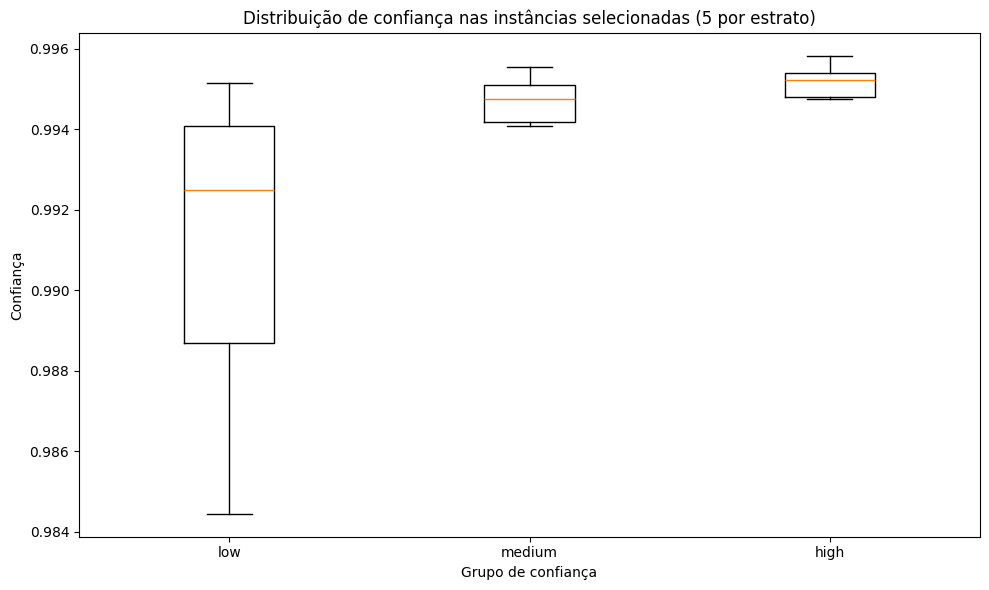

In [21]:
if "confidence_group_std" in selected_std.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    group_order = ["low", "medium", "high"]
    data = [
        selected_std.loc[selected_std["confidence_group_std"] == g, "confidence_std"].dropna().values
        for g in group_order
    ]
    ax.boxplot(data, labels=group_order, showfliers=False)
    ax.set_title("Distribuição de confiança nas instâncias selecionadas (5 por estrato)")
    ax.set_xlabel("Grupo de confiança")
    ax.set_ylabel("Confiança")

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "selected_confidence_by_group_boxplot.png", dpi=200)
    plt.show()

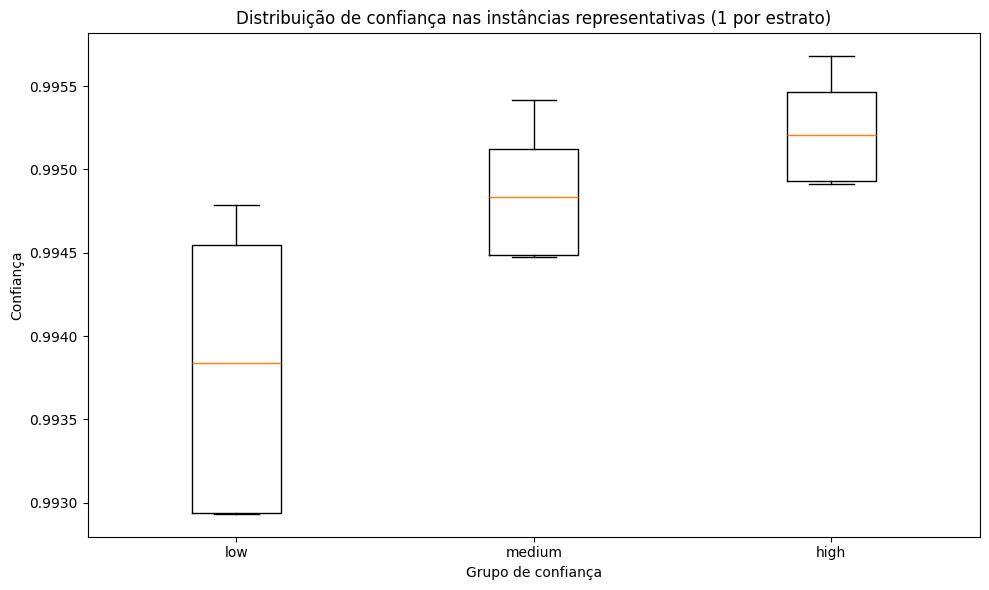

In [22]:
if "confidence_group_std" in selected_rep1_std.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    group_order = ["low", "medium", "high"]
    data = [
        selected_rep1_std.loc[selected_rep1_std["confidence_group_std"] == g, "confidence_std"].dropna().values
        for g in group_order
    ]
    ax.boxplot(data, labels=group_order, showfliers=False)
    ax.set_title("Distribuição de confiança nas instâncias representativas (1 por estrato)")
    ax.set_xlabel("Grupo de confiança")
    ax.set_ylabel("Confiança")

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "selected_rep1_confidence_by_group_boxplot.png", dpi=200)
    plt.show()

## 8. Exportar tabelas-resumo

In [23]:
quartis.to_csv(OUTPUT_DIR / "quartis_confidence_by_class.csv")
if "confidence_group_std" in grouped_std.columns:
    counts_grouped.to_csv(OUTPUT_DIR / "counts_grouped_class_x_confidence.csv")
if "confidence_group_std" in selected_std.columns:
    counts_selected.to_csv(OUTPUT_DIR / "counts_selected_class_x_confidence.csv")
if "confidence_group_std" in selected_rep1_std.columns:
    counts_selected_rep1.to_csv(OUTPUT_DIR / "counts_selected_rep1_class_x_confidence.csv")

print(f"Arquivos salvos em: {OUTPUT_DIR.resolve()}")

Arquivos salvos em: /scratch/samiramalaquias/lei-local/src_novo/selecao-instancias/figures_instance_selection


## 9. Próximas visualizações recomendadas

Quando você já tiver os resultados do GA e dos outros métodos, vale adicionar:

- confiança inicial vs distância mínima de flip
- confiança inicial vs evals-to-first-flip
- probabilidade de flip vs raio
- curvas anytime por método
- distância vs margem
- heatmap método × grupo de confiança com success rate

Também pode valer comparar:
- desempenho do GA nas 30 instâncias representativas
- desempenho do GA num subconjunto das 150 instâncias